In [2]:
%matplotlib widget 
# Uncomment for interactive plots when running the notebook!

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from time import perf_counter

import import_ipynb

import PyPO
from PyPO.System import System
from PyPO.Enums import Projections, Objects, Units, Scales, FieldComponents, CurrentComponents

In [3]:
# This code allows us to display global variables within markdown output, by overriding the %%markdown magic
from IPython.display import Markdown
from IPython.core.magic import register_cell_magic

@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

In [4]:
# Create the optical system
s = System()

2026-03-17 15:21:44 - WARNING - System override set to True. 


# Import SMA antenna parameters

We import the SMA antenna parameters from the `./design/sma_antenna_design.ipynb` notebook

In [5]:
# SMA antenna parameters

# Primary reflector
from design.sma_antenna_design import D_p, F_p, D_s, c_s, a_s, e_s, z_sh, f_s2, alpha, h_p

# Calculate distance from secondary edge plane to Cass focus
z_sef2 = (f_s2 + z_sh)

Primary Focal Length (F_p) : 2.520 m
Primary Rim Height (h_p): 0.893 m
Angle of edge ray (alpha) :61.52543906847784°
Vertical distance from prime focus to secondary edge plane (z_sedge1): 0.094917 m
Distance from prime focus to secondary edge plane (r_sedge1): 0.094916667 m
Angle of edge ray from Cassegrain focus to secondary edge (thetae) 2.0462388063868757°
Distance from Cassegrain focus to secondary edge (r_sedge2) 4.901135272577161 m
Subreflector eccentricity (e_s): 1.0618612323260763

Subreflector conic constant (k): -1.1275492767170534
Subreflector distance to vertex (a_s) : 2.351025969621911 m
Subreflector distance to focus (c_s): 2.496463333333331 m
Subreflector distance between foci (2 c_s) : 4.992926666666662 m
Ratio between distance between foci and Primary focal length (2 c_s/F_p) : 1.981320105820104
Subreflector (b_s) : 0.8396463927398957 m

Subreflector radius of curvature on axis (R_s): 0.28240193053417684 m
Subreflector input focal distance (f_s1) : 0.1454373637114199 m

In [6]:
%%markdown 
## Imported Antenna parameters

| Parameter | Variable | Value | Unit |
| --- | --- | --: | --- |
| Primary Diameter | `D_p` | {D_p:.3f} | m |
| Primary Focal Length | `F_p` | {F_p:.3f} | m |
| Angle of edge ray | `alpha` | {alpha:.3f} | rad |
| Secondary Diameter | `D_s` | {D_s:.3f} | m | 
| Secondary Distance to Foci | `c_s` | {c_s:.6f} | m |
| Secondary Distance to Vertex | `a_s` | {a_s:.6f} | m |
| Secondary Eccentricity | `e_s` | {e_s:.6f} |   |
| Height of Secondary | `z_sh` | {z_sh:.6f} | m |
| Distance from Secondary to Focus | `z_sef2` | {z_sef2:.3f} | m |

## Imported Antenna parameters

| Parameter | Variable | Value | Unit |
| --- | --- | --: | --- |
| Primary Diameter | `D_p` | 6.000 | m |
| Primary Focal Length | `F_p` | 2.520 | m |
| Angle of edge ray | `alpha` | 1.074 | rad |
| Secondary Diameter | `D_s` | 0.350 | m | 
| Secondary Distance to Foci | `c_s` | 2.496463 | m |
| Secondary Distance to Vertex | `a_s` | 2.351026 | m |
| Secondary Eccentricity | `e_s` | 1.061861 |   |
| Height of Secondary | `z_sh` | 0.050521 | m |
| Distance from Secondary to Focus | `z_sef2` | 4.898 | m |


# Define a Gaussian feed

We initially define a Gaussian feed at the Cassegrain focus, with an -12 dB edge taper at the plane of the secondary edge, as a basic example of a Cassegrain antenna calculation

In [7]:
# Wavelength in millimeters
lam = 1.3*Units.MM

# Gaussian feed parameters
edge_taper_db = -12.0 # Gaussian edge taper

# beam width at secondary
beamwidth_s = D_s*Units.M / 2 / ( 0.3393 * np.sqrt(-edge_taper_db))

# Calculate beam width at Cassegrain focus using Gaussian beam propagation
beamwidth_cass = beamwidth_s * np.sqrt((1 - np.sqrt(1 - (2*lam*(z_sef2*Units.M) / (np.pi*beamwidth_s**2))**2 ) )/2)
w_0 = beamwidth_cass

# Farfield divergence angle
theta_0 = np.rad2deg(lam / (np.pi*w_0))

# Directivity of feed
gain_feed = 8*np.pi**2*w_0**2/lam**2
gain_feed_db = 10*np.log10(gain_feed)

# Rayleigh range
rayleigh_range = np.pi*w_0**2 / lam
z_R = rayleigh_range

In [8]:
%%markdown

## Gaussian feed parameters

| Parameter | Variable | Value | Unit |
| --- | --- | --: | --- |
| Wavelength | `lam` | {lam:.3f} | mm |
| Beam waist | `w_0` | {w_0:.3f} | mm |
| Rayleigh range | `z_R` | {z_R:.3f} | mm |
| Farfield HWHM  | `theta_0` | {theta_0:.3f} | ° |
| Gain of feed  | `gain_feed` | {gain_feed_db:.3f} | dBi |


## Gaussian feed parameters

| Parameter | Variable | Value | Unit |
| --- | --- | --: | --- |
| Wavelength | `lam` | 1.300 | mm |
| Beam waist | `w_0` | 13.671 | mm |
| Rayleigh range | `z_R` | 451.630 | mm |
| Farfield HWHM  | `theta_0` | 1.734 | ° |
| Gain of feed  | `gain_feed` | 39.411 | dBi |


In [9]:
feed_plane_r = 2.5*w_0

## Calculate the required feed_plane size
z = 1.09*np.pi*2.5*feed_plane_r/lam*np.sin(np.atan(D_s*Units.MM/2 / (2*c_s*Units.MM))) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(2*10*w_0/lam)
max_po2 = int(2*np.pi*2*feed_plane_r/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

17.883467528695263
Estimated Grid size : (7, 17)
Maximum Grid size   : (210, 330)


In [10]:
# The feed plane defines the source fields - it needs sufficient size and resolution to
# contain the feed.
feed_plane = {
            "name"      : "feed_plane",
            "gmode"     : "uv",
            "lims_u"    : np.array([0, w_0*2.5])*Units.MM,
            "lims_v"    : np.array([0, 360]),
            "gridsize"  : np.array([max_po1, max_po2])
            }

s.addPlane(feed_plane)

2026-03-17 15:21:44 - INFO - Added plane feed_plane to system. 


In [11]:
# Create a Gaussian field in the feed plane

feed_dict = {                                                                                                                                                                     
            "name"    : "gaussian_feed",                                                                                                                                  
            "lam"     : lam,                                                                                                      
            "w0"      : w_0,                                                                                             
            "z"       : 0.0*Units.MM                                                                                                        
}

s.createGaussianBeam(feed_dict, "feed_plane")

# Move the feed plane to the Cassegrain focus
s.translateGrids("feed_plane", np.array([0, 0, F_p - 2*c_s])*Units.M)

2026-03-17 15:21:44 - INFO - Translated element feed_plane by ('0.000e+00', '0.000e+00', '-2.473e+03') millimeters. 


In [12]:
feed_grid = s.generateGrids('feed_plane')

## Surface Currents at source

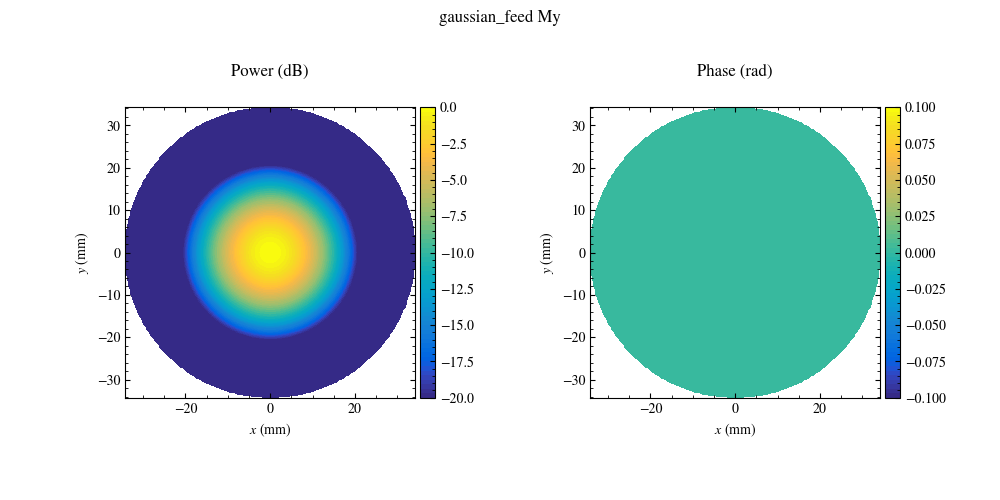

In [13]:
s.plotBeam2D('gaussian_feed', PyPO.Enums.CurrentComponents.My, vmin=-20)

# Define the reflectors

In [14]:
## Calculate the required secondary grid size
z = 1.09*np.pi*D_s*Units.M/lam*np.sin(alpha) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(D_s*Units.M/lam)
max_po2 = int(2*np.pi*D_s*Units.M/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

820.408910848911
Estimated Grid size : (341, 820)
Maximum Grid size   : (269, 1691)


In [ ]:
secondary = {
            "name"      : "secondary",
            "pmode"     : "focus",
            "gmode"     : "uv",
            "flip"      : True,
            "focus_1"   : np.array([0, 0, F_p])*Units.M,
            "focus_2"   : np.array([0, 0, F_p - 2*c_s])*Units.M,
            "ecc"       : e_s,
            "lims_u"    : np.array([0, D_s/2])*Units.M,
            "lims_v"    : np.array([0, 360]),
            "gridsize"  : np.array([315, 780])
            }
s.addHyperbola(secondary)


2026-03-17 15:21:45 - INFO - Added hyperboloid secondary to system. 


In [16]:
sec_grid = s.generateGrids("secondary")


In [17]:
## Calculate the required primary grid size
ff_size = 10*Units.DEG
z = 1.09*np.pi*D_p*Units.M/lam*np.sin(np.deg2rad(ff_size)) + 10
print(z)

po1 = int(z/2.4)
po2 = int(z)

max_po1 = int(D_p*Units.M/lam)
max_po2 = int(2*np.pi*D_p*Units.M/lam)

print(f"Estimated Grid size : ({po1:d}, {po2:d})")
print(f"Maximum Grid size   : ({max_po1:d}, {max_po2:d})")

2754.444791392808
Estimated Grid size : (1147, 2754)
Maximum Grid size   : (4615, 28999)


In [ ]:

primary = {
            "name"      : "primary",
            "pmode"     : "focus",
            "gmode"     : "uv",
            "vertex"    : np.zeros(3),
            "focus_1"   : np.array([0, 0, F_p])*Units.M,
            "lims_u"    : np.array([D_s/2, D_p/2])*Units.M,
            "lims_v"    : np.array([0, 360]),
            "gridsize"  : np.array([260, 80])
            }

s.addParabola(primary)

2026-03-16 10:21:04 - INFO - Added paraboloid primary to system. 


In [ ]:
pri_grid = s.generateGrids("primary")

# Define the output field planes

In [ ]:
secondary_edge_plane = {
            "name"      : "sec_plane",
            "gmode"     : "uv",
            "lims_u"    : np.array([0, D_s/2])*Units.M,
            "lims_v"    : np.array([0, 359]),
            "gridsize"  : np.array([301, 360])
            }
s.addPlane(secondary_edge_plane)

s.translateGrids("sec_plane", np.array([0.0, 0.0, F_p - (c_s - a_s) + z_sh])*Units.M)

ff_size = 0.05*Units.DEG
ff_ngrid = 301

farfield_plane = {
            "name"      : "farfield_plane",
            "gmode"     : "AoE",
            "lims_Az"    : np.array([-1.0, 1.0])*ff_size,
            "lims_El"    : np.array([-1.0, 1.0])*ff_size,
            "gridsize"  : np.array([ff_ngrid, ff_ngrid])
            }
s.addPlane(farfield_plane)

2026-03-16 10:21:12 - INFO - Added plane sec_plane to system. 
2026-03-16 10:21:12 - INFO - Translated element sec_plane by ('0.000e+00', '0.000e+00', '2.425e+03') millimeters. 
2026-03-16 10:21:12 - INFO - Added plane farfield_plane to system. 
